<a href="https://colab.research.google.com/github/arman-hossain45/Convolution-Neural-Network/blob/main/CNN_fashion_mnist_pytorch_gpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [34]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [35]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [36]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [37]:
df.shape

(6000, 785)

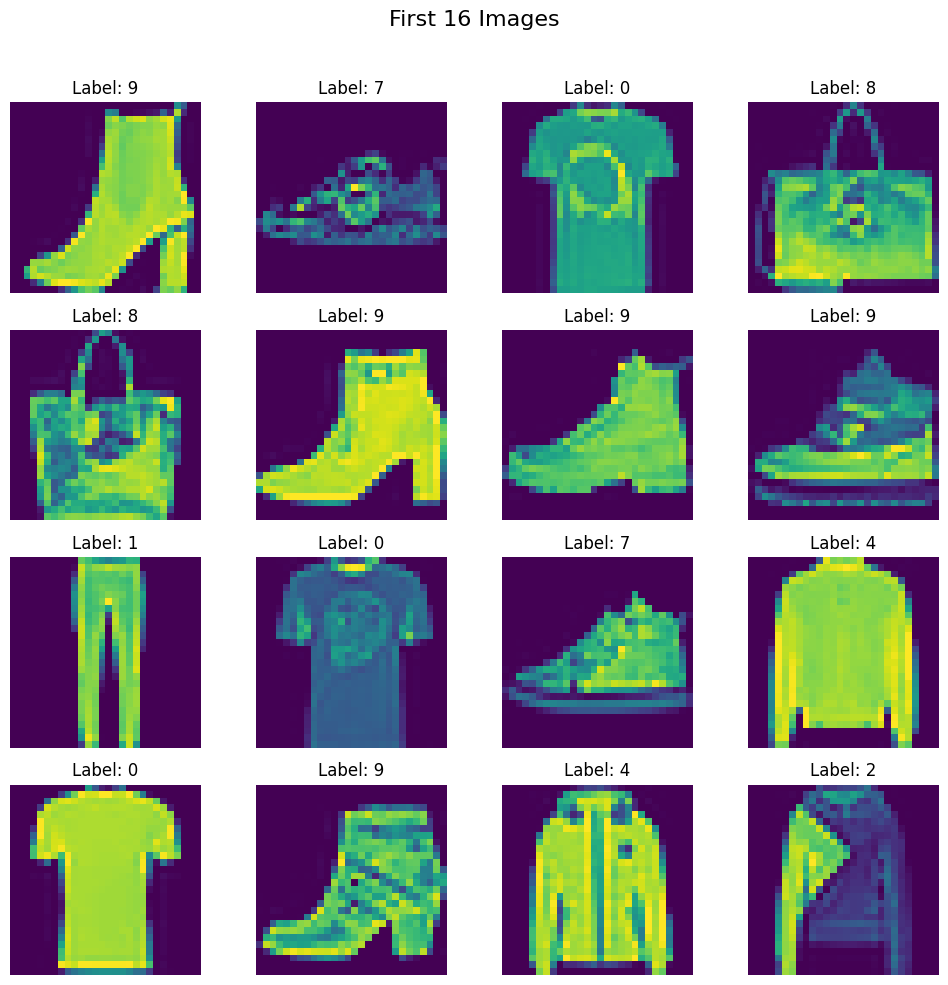

In [38]:

# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [39]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
X_train = X_train/255.0
X_test = X_test/255.0

In [42]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28)#ai khan a 1D dey tai amra atake 2D te convert korbo
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [43]:
train_dataset = CustomDataset(X_train, y_train)

In [44]:
test_dataset = CustomDataset(X_test, y_test)

In [45]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [46]:
len(train_loader)

150

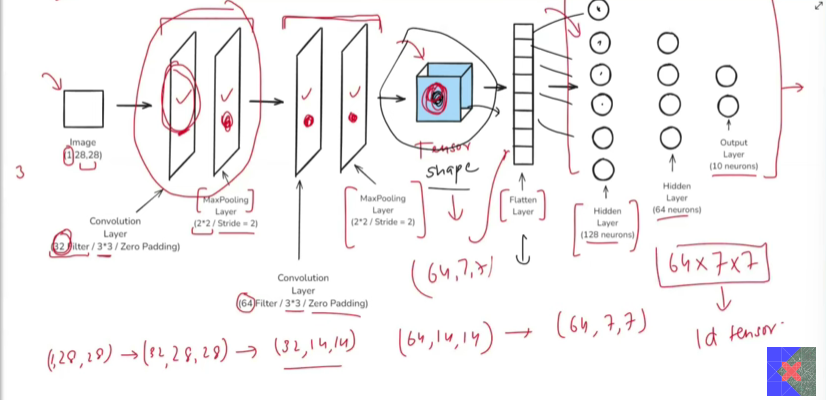

In [47]:
from torch.nn.modules.pooling import MaxPool2d
from torch.nn.modules.activation import ReLU
class MyNN(nn.Module):

  def __init__(self, input_features):

    super().__init__()
    # feature extraction model
    self.features = nn.Sequential(#32 totall kernel number and 3 is kernel size
        nn.Conv2d(input_features, 32,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2,stride=2),

        nn.Conv2d(32,64,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2,stride=2),

    )# here  code is ANN fist we do that images flatten then apply ann
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7,128),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(64,10)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)

    return x


In [48]:
learning_rate = 0.1
epochs = 100

In [49]:
# instatiate the model
model = MyNN(1)

model = model.to(device)

# loss function
criterion = nn.CrossEntropyLoss()
# optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [50]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 1.0362668045361836
Epoch: 2 , Loss: 0.6480400105317433
Epoch: 3 , Loss: 0.5780671255787214
Epoch: 4 , Loss: 0.5202573115626971
Epoch: 5 , Loss: 0.4819143754243851
Epoch: 6 , Loss: 0.42022069948414964
Epoch: 7 , Loss: 0.3868480656047662
Epoch: 8 , Loss: 0.3720998165135582
Epoch: 9 , Loss: 0.3538349902629852
Epoch: 10 , Loss: 0.2996347443262736
Epoch: 11 , Loss: 0.2921815453469753
Epoch: 12 , Loss: 0.31281903353830176
Epoch: 13 , Loss: 0.3057029314835866
Epoch: 14 , Loss: 0.253657439922293
Epoch: 15 , Loss: 0.25726559840142726
Epoch: 16 , Loss: 0.21012191598614058
Epoch: 17 , Loss: 0.19213006004691124
Epoch: 18 , Loss: 0.19012784245734413
Epoch: 19 , Loss: 0.19593959388012688
Epoch: 20 , Loss: 0.1806548081835111
Epoch: 21 , Loss: 0.19436026063747705
Epoch: 22 , Loss: 0.1579530135790507
Epoch: 23 , Loss: 0.14976478194197018
Epoch: 24 , Loss: 0.13823412305054567
Epoch: 25 , Loss: 0.1394721490268906
Epoch: 26 , Loss: 0.13970465530330936
Epoch: 27 , Loss: 0.10937219476016859

In [51]:
model.eval()

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [52]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8708333333333333


In [53]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():
# see the accuracy in the test data set
  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8708333333333333


In [54]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():
# we see the same accuracy in the train data set it show the overfitting
  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9997916666666666


our model show some overfitting on  train data which is 0.99 percent in this next module how to remove  this